In [2]:
import xarray as xr
import matplotlib.transforms as mtransforms
from cmcrameri import cm
from matplotlib import rc
from mpl_toolkits.axes_grid1 import ImageGrid

In [9]:
# load landcover and anette's landcover! (first normal landcover)
land_cover = xr.open_dataset('/mnt/data7/nfs4/avh_ndvi/sdupuis/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7b.nc', engine='netcdf4')

In [10]:
lc = land_cover.sel(lat=slice(72,55), lon=slice(-168,-150))

In [6]:
std_anoms_day_al = xr.open_dataset('../anomaly_cubes/output_data/standard_anomalies_alaska_day.nc')

In [11]:
lc_interp = lc.interp(lat=std_anoms_day_al.coords['lat'], lon=std_anoms_day_al.coords['lon'], method='nearest')

In [12]:
subset = std_anoms_day_al.sel(lat=slice(55,72), lon=slice(-168,-150))

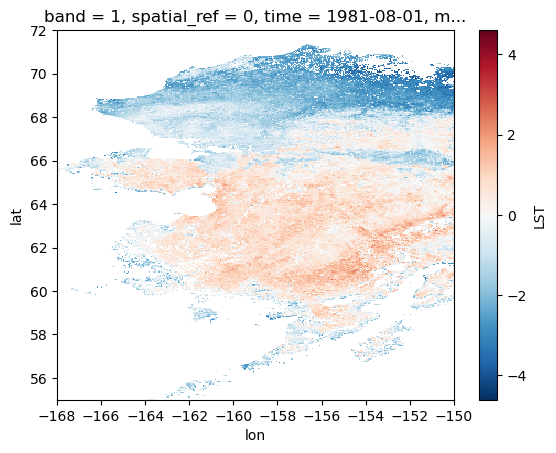

In [ ]:
subset['LST'].isel(time=0).plot();

In [15]:
anoms_scfg = xr.open_dataset('output_data/standard_anoms_scfg.nc')

In [88]:
anoms_swe = xr.open_dataset('output_data/standard_anoms_swe.nc')

In [94]:
subset_swe = anoms_swe['swe'].sel(lat=slice(55,72), lon=slice(-168,-150), time=slice('1981-08', '2018'))

In [24]:
subset_snow = anoms_scfg['scfg'].sel(lat=slice(55,72), lon=slice(-168,-150))

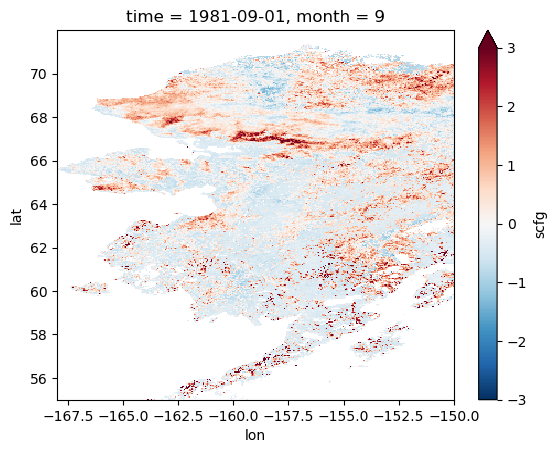

In [ ]:
anoms_scfg['scfg'].sel(lat=slice(55,72), lon=slice(-168,-150)).isel(time=1).plot(vmax=3);

In [95]:
subset_swe

<xarray.DataArray 'swe' (time: 449, lat: 170, lon: 180)>
[13739400 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 55.05 55.15 55.25 55.35 ... 71.65 71.75 71.85 71.95
  * lon      (lon) float64 -168.0 -167.9 -167.8 -167.7 ... -150.3 -150.2 -150.1
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
    month    (time) int64 ...

In [97]:
#interp swe
anoms_swe_interp = subset_swe.interp(lat=subset.coords['lat'], lon=subset.coords['lon'], method='nearest')

In [99]:
anoms_swe_interp_aligned, da2 = xr.align(anoms_swe_interp, subset, join="inner")

In [100]:
anoms_swe_interp_aligned

<xarray.DataArray 'swe' (time: 446, lat: 340, lon: 360)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time         (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
  * lat          (lat) float32 55.03 55.08 55.12 55.17 ... 71.88 71.93 71.97
  * lon          (lon) float32 -168.0 -167.9 -167.9 ... -150.1 -150.1 -150.0
    month        (time) int64 8 9 10 11 12 1 2 3 4 5 ... 3 4 5 6 7 8 9 10 11 12
    band         int64 1
    spatial_ref  int64 0

In [25]:
subset_snow

<xarray.DataArray 'scfg' (time: 447, lat: 340, lon: 360)>
[54712800 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 55.03 55.08 55.12 55.17 ... 71.82 71.88 71.93 71.97
  * lon      (lon) float64 -168.0 -167.9 -167.9 -167.8 ... -150.1 -150.1 -150.0
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
    month    (time) int64 ...

In [102]:
swe_large_anoms = anoms_swe_interp_aligned.where((subset['LST'] > 1.0) & (subset['LST'] < 3.0))
swe_pos = swe_large_anoms.where(swe_large_anoms > 1)
swe_neg = swe_large_anoms.where(swe_large_anoms < -1)

In [103]:
swe_neg_season_count = (
    swe_neg
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)
swe_pos_season_count = (
    swe_pos
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)

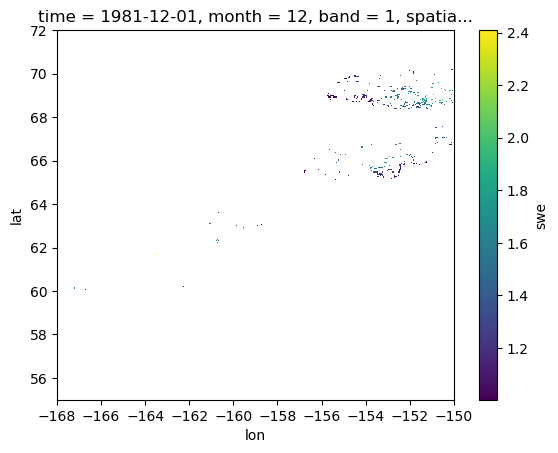

In [109]:
swe_pos.isel(time=4).plot();

In [27]:
snow_large_anoms = subset_snow.where((subset['LST'] > 1.0) & (subset['LST'] < 3.0))

In [30]:
snow_pos = snow_large_anoms.where(snow_large_anoms > 1)

In [37]:
snow_neg = snow_large_anoms.where(snow_large_anoms < -1)

In [40]:
snow_neg_season_count = (
    snow_neg
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)

In [35]:
snow_pos_season_count = (
    snow_pos
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)


In [ ]:
snow_pos_season_count.sel(season="DJF").plot();

In [63]:
snow_neg_season_count.sel(season="JJA").values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

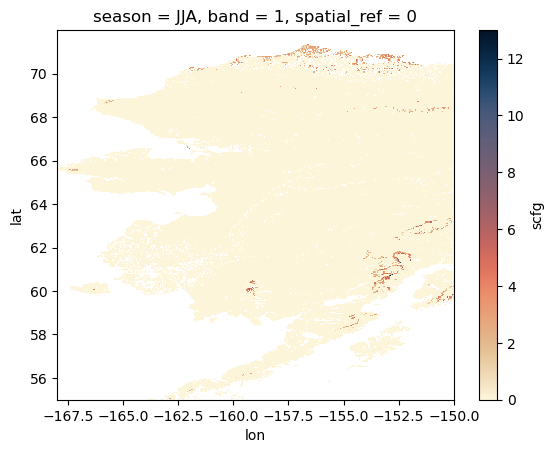

In [62]:
snow_neg_season_count.sel(season="JJA").plot(cmap=cm.lipari_r);

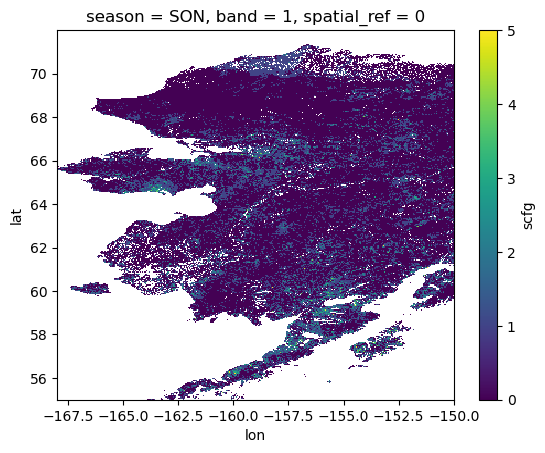

In [53]:
snow_pos_season_count.sel(season="SON").plot();

In [50]:
vmax = max(
    snow_neg_season_count.max(),
    snow_pos_season_count.max()
).item()

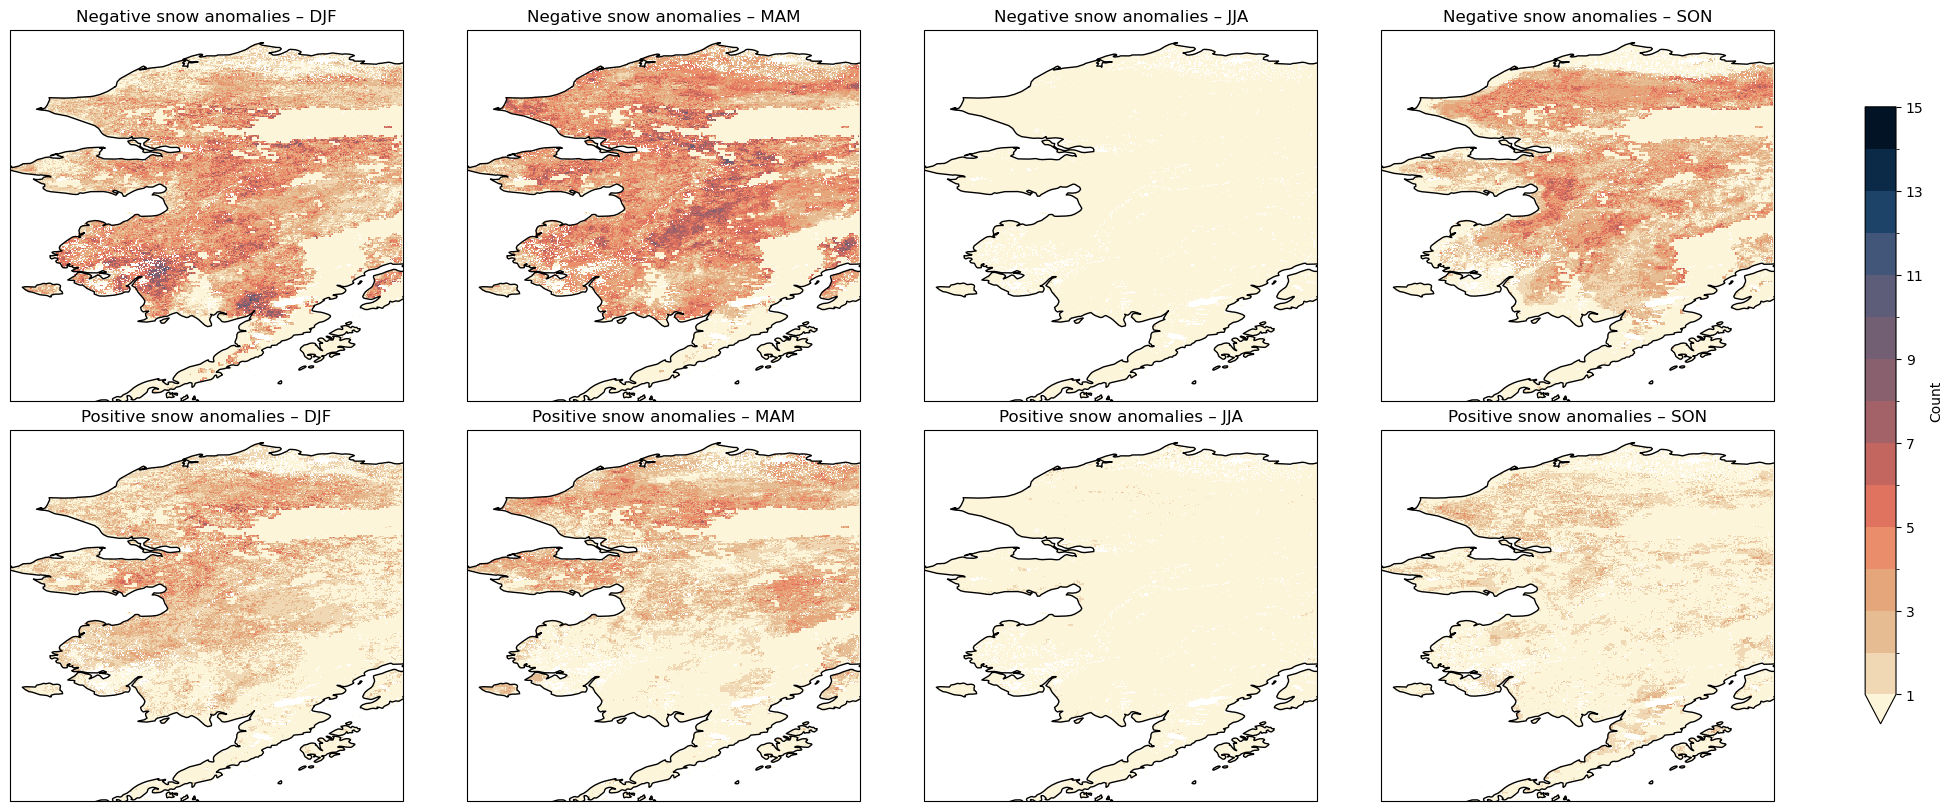

In [110]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(20, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# --- Row 1: negative snow anomalies ---
for i, season in enumerate(seasons):
    swe_neg_season_count.sel(season=season).plot(
        ax=axes[0, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=15
    )
    axes[0, i].set_title(f"Negative snow anomalies – {season}")
    axes[0, i].coastlines()

# --- Row 2: positive snow anomalies ---
for i, season in enumerate(seasons):
    swe_pos_season_count.sel(season=season).plot(
        ax=axes[1, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=15
    )
    axes[1, i].set_title(f"Positive snow anomalies – {season}")
    axes[1, i].coastlines()

# --- One shared colorbar (optional but recommended) ---
cbar = fig.colorbar(
    axes[1, 0].collections[0],
    ax=axes,
    
    orientation="vertical",
    shrink=0.8,
    label="Count"
)


plt.savefig('swe_alaska.png')
plt.show()


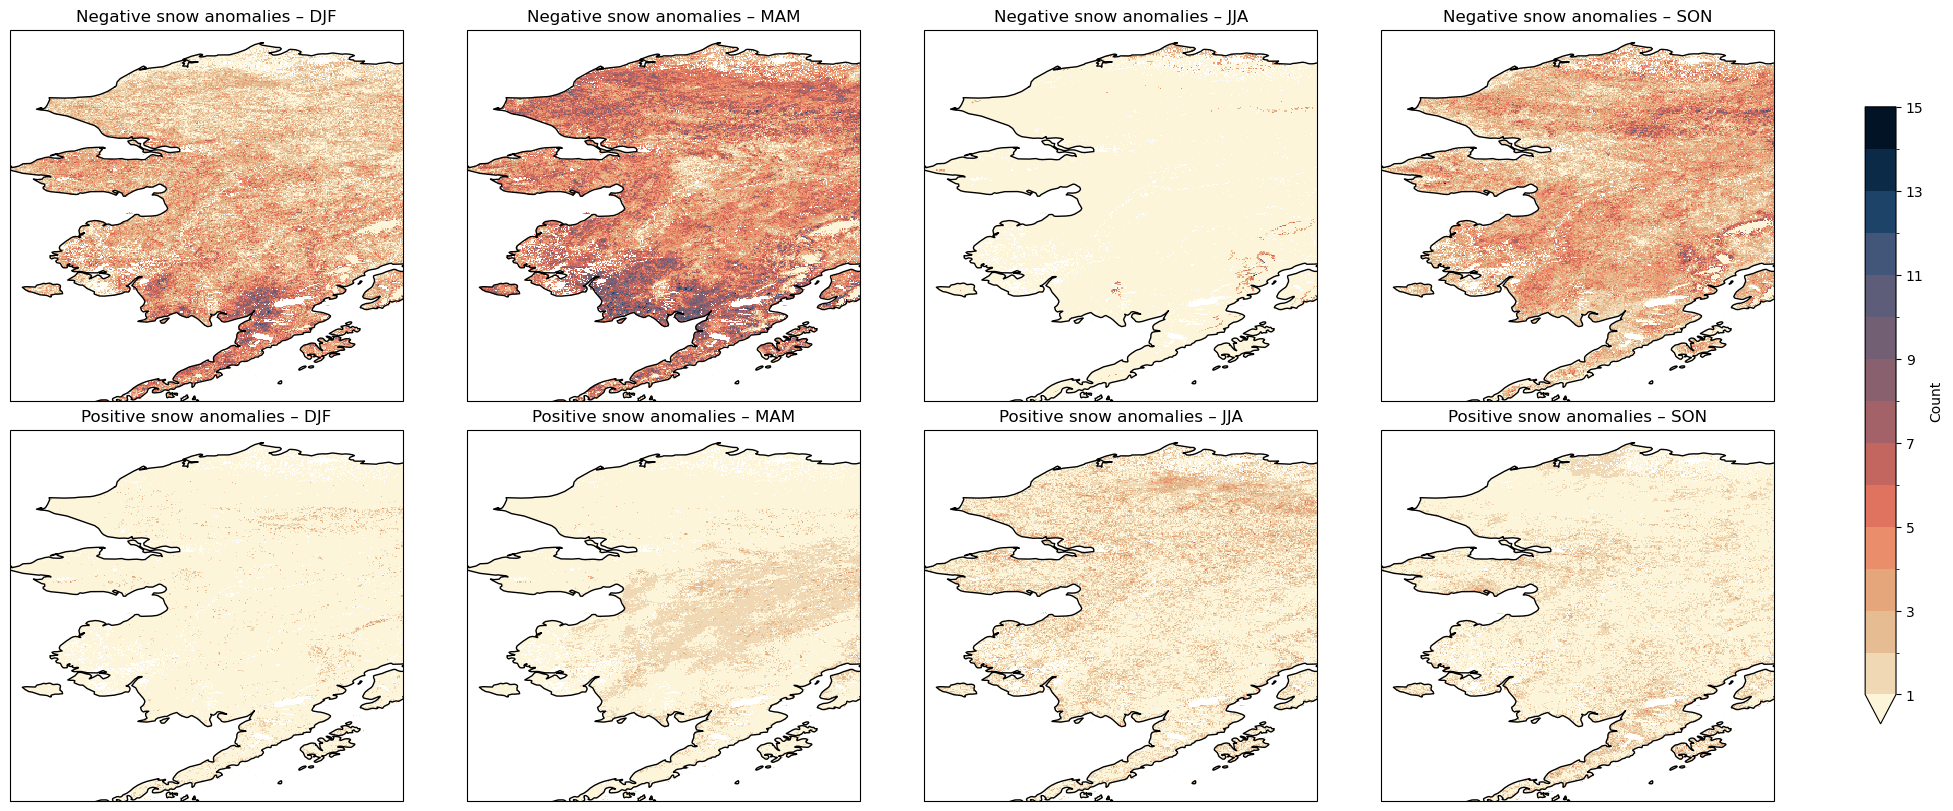

In [87]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(20, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# --- Row 1: negative snow anomalies ---
for i, season in enumerate(seasons):
    snow_neg_season_count.sel(season=season).plot(
        ax=axes[0, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=15
    )
    axes[0, i].set_title(f"Negative snow anomalies – {season}")
    axes[0, i].coastlines()

# --- Row 2: positive snow anomalies ---
for i, season in enumerate(seasons):
    snow_pos_season_count.sel(season=season).plot(
        ax=axes[1, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=15
    )
    axes[1, i].set_title(f"Positive snow anomalies – {season}")
    axes[1, i].coastlines()

# --- One shared colorbar (optional but recommended) ---
cbar = fig.colorbar(
    axes[1, 0].collections[0],
    ax=axes,
    
    orientation="vertical",
    shrink=0.8,
    label="Count"
)


plt.savefig('snow_alaska.png')
plt.show()


In [ ]:
# do SWE
swe_large_anoms = subset_snow.where((subset['LST'] > 1.0) & (subset['LST'] < 3.0))

In [ ]:
# yamal 

In [84]:
import cartopy.crs as ccrs

for i, season in enumerate(seasons):

    ax = axes[0, i]
    snow_neg_season_count.sel(season=season).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cm.lipari_r, levels=15,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"Negative – {season}")

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax = axes[1, i]
    snow_pos_season_count.sel(season=season).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cm.lipari_r, levels=15,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"Positive – {season}")

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

plt.show()

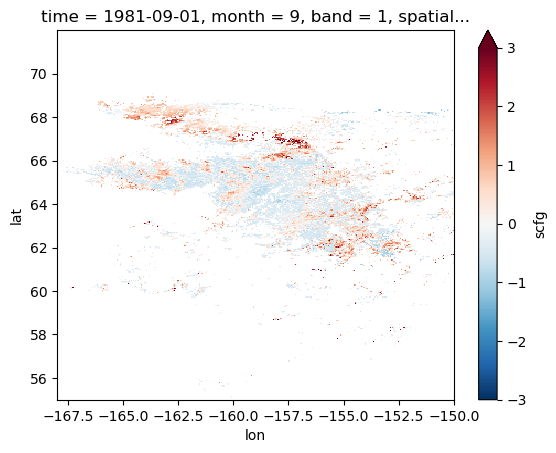

In [29]:
snow_large_anoms.isel(time=1).plot(vmax=3)

In [3]:
std_anoms_day = xr.open_dataset('../anomaly_cubes/output_data/standard_anomalies_Greenland_day.nc')

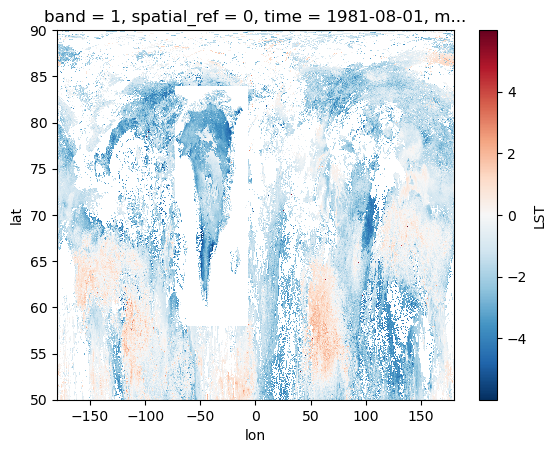

In [5]:
std_anoms_day['LST'].isel(time=0).plot();

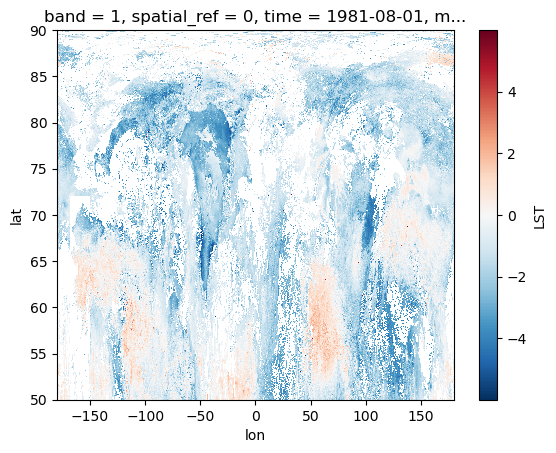

In [8]:
std_anoms_day_al['LST'].isel(time=0).plot();